# Trend Convexity

# Path Management & Files

In [1]:
import os
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
from   matplotlib.ticker import FuncFormatter

# Analyzing Hedge Fund and CTA Returns

In [2]:
hf_path = r"A:\2026BlpAdHocData\Combined\PX\hf_indices.parquet"
eq_path = r"A:\2026BlpAdHocData\Combined\PX\EquityIndices.parquet"

df_hf = pd.read_parquet(path = hf_path, engine = "pyarrow")

renamer = {
    "BARCBTOP": "Barclay CTA",
    "HFRIFWI" : "Hedge Fund Composite Index",
    "NEIXCTA" : "SocGen CTA Index"}

In [3]:
df_spx = (pd.read_parquet(
    path = eq_path, engine = "pyarrow").
    query("security == 'SPX Index'").
    set_index("date").
    sort_index().
    assign(px_val = lambda x: np.cumprod(1 + (x.RT112 / 100)) * 100)
    [["px_val"]].
    rename(columns = {"px_val": "spx_rebuilt"}))

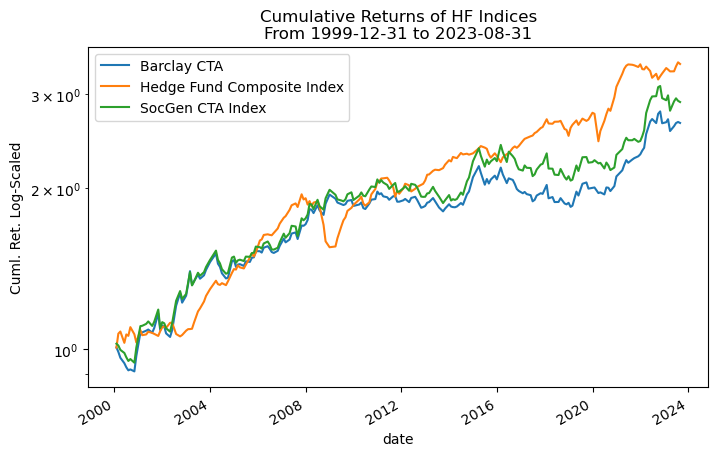

In [4]:
df_plot = (df_hf.assign(
    security = lambda x: x.security.str.split(" ").str[0]).
    rename(columns = {"security": ""}).
    pivot(index = "date", columns = "", values = "PX_LAST").
    dropna().
    pct_change().
    apply(lambda x: np.cumprod(1 + x)))
    
(df_plot.
    rename(columns = renamer).
    plot(
        figsize = (8,5),
        logy    = True,
        ylabel  = "Cuml. Ret. Log-Scaled",
        title   = "Cumulative Returns of HF Indices\nFrom {} to {}".format(
            df_plot.index.min().date(),
            df_plot.index.max().date())))

plt.show()

In [5]:
df_wider = (df_hf.assign(
    security = lambda x: x.security.str.split(" ").str[0]).
    rename(columns = {"security": ""}).
    pivot(index = "date", columns = "", values = "PX_LAST").
    dropna().
    merge(right = df_spx, how = "inner", on = ["date"]).
    rename(columns = {"spx_rebuilt": "SPX"}).
    pct_change().
    dropna())

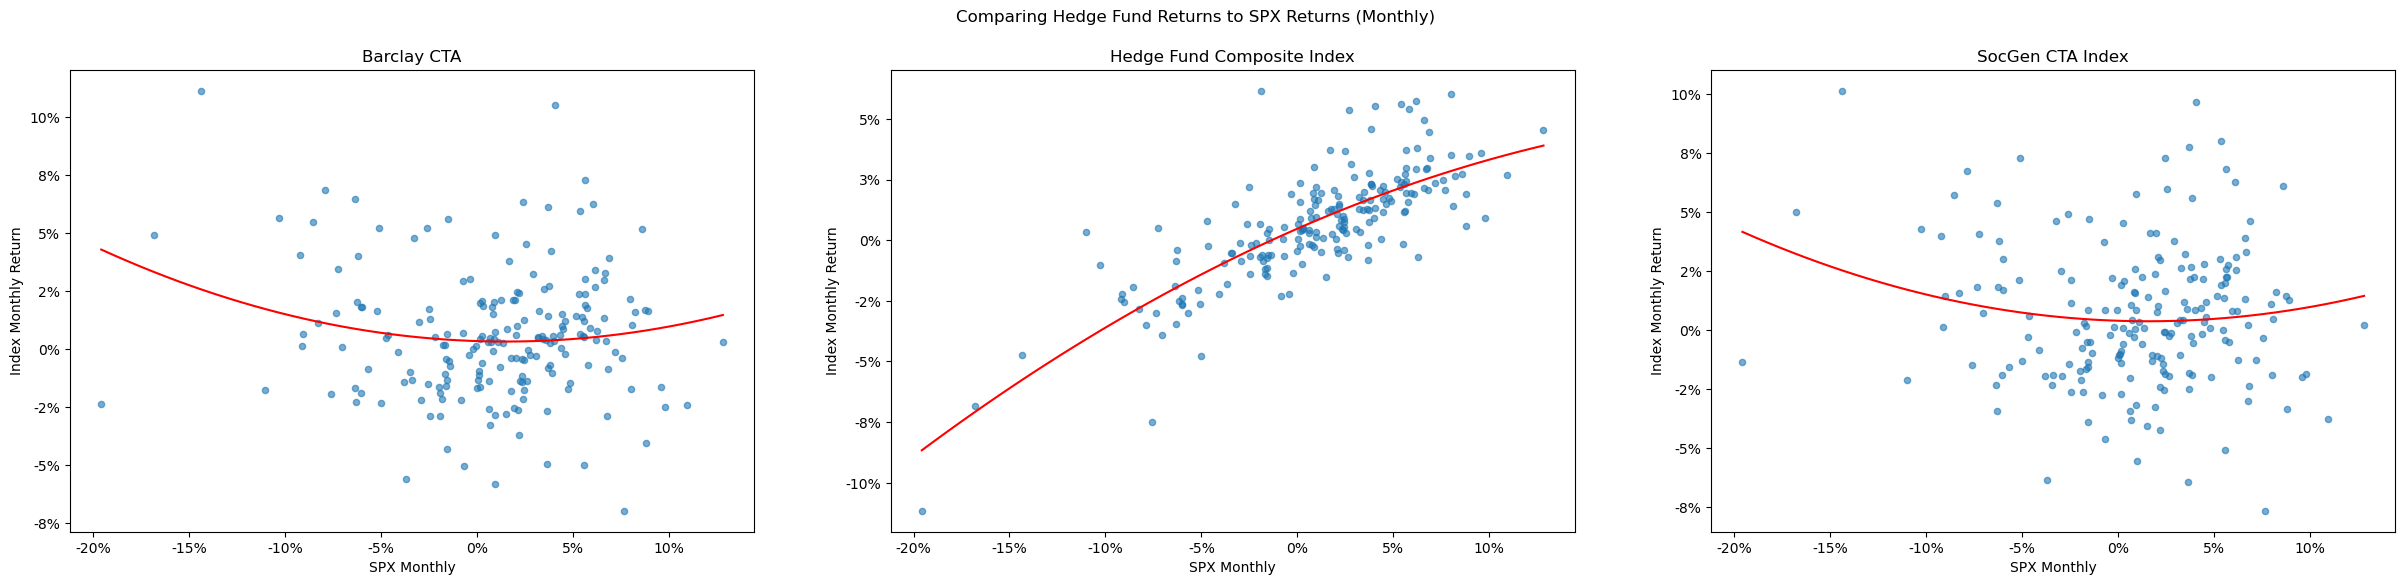

In [6]:
df_longer = (df_wider.reset_index().melt(
    id_vars = ["date", "SPX"]))

variables = df_longer.variable.drop_duplicates().sort_values().to_list()
fig, axes = plt.subplots(ncols = len(variables), figsize = (30,6))

for variable, ax in zip(variables, axes.flatten()): 

    df_tmp = df_longer.query("variable == @variable")

    poly_model = (np.poly1d(np.polyfit(
        x   = df_tmp.SPX,
        y   = df_tmp.value,
        deg = 2)))

    x = np.linspace(
        start = df_tmp.SPX.min(),
        stop  = df_tmp.SPX.max())
    
    y = poly_model(x)

    (df_tmp.plot(
        alpha  = 0.6,
        kind   = "scatter",
        x      = "SPX",
        y      = "value",
        ax     = ax,
        title  = renamer[variable],
        ylabel = "Index Monthly Return",
        xlabel = "SPX Monthly"))

    ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{y*100:.0f}%"))
    ax.xaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{y*100:.0f}%"))
    ax.plot(x, y, color = "red")

fig.suptitle("Comparing Hedge Fund Returns to SPX Returns (Monthly)")
plt.show()

In [7]:
def _get_ols(df: pd.DataFrame) -> pd.DataFrame: 
    
    model = (sm.OLS(
        endog = df.value,
        exog  = sm.add_constant(df.SPX)).
        fit())
    
    df_out = (pd.DataFrame({
        "param_val": model.params,
        "p_value"  : model.pvalues,
        "t_stat"   : model.tvalues}))
    
    return df_out

(df_wider.assign(
    SPX = lambda x: x.SPX ** 2).
    reset_index().
    melt(id_vars = ["date", "SPX"]).
    set_index("date").
    groupby("variable").
    apply(_get_ols).
    reset_index().
    rename(columns = {
        "variable" : "Index Name",
        "level_1"  : "Param",
        "param_val": "Param Val",
        "p_value"  : "$p$-value",
        "t_stat"   : "$t$-stat"}).
    replace(renamer).
    replace({"SPX": r"SPX$^2$"}).
    set_index("Index Name"))

,Param,Param Val,$p$-value,$t$-stat
Index Name,,,,
Barclay CTA,const,0.002979,1.895829e-01,1.316383
Barclay CTA,SPX$^2$,0.978276,2.901307e-02,2.199483
Hedge Fund Composite Index,const,0.011088,1.020273e-08,5.983689
Hedge Fund Composite Index,SPX$^2$,-1.717339,4.571726e-06,-4.715433
SocGen CTA Index,const,0.003479,1.569091e-01,1.420988
SocGen CTA Index,SPX$^2$,0.931529,5.428221e-02,1.936194
